In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [18]:
df=pd.read_csv('dataset\PCOS_extended_dataset.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\nandi\AppData\Local\Temp\ipykernel_416\2226844563.py:1: SyntaxWarning: invalid escape sequence '\P'
  df=pd.read_csv('dataset\PCOS_extended_dataset.csv')


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,193,193,0,30,69.979147,167.708055,23.185569,12,72,22,...,1,0.0,1,105.483401,76.096379,2,4,10.0,13.0,6.176029
1,360,360,0,36,63.711688,154.055877,25.441392,13,70,18,...,1,0.0,1,115.883740,79.117243,2,3,13.0,11.0,6.824718
2,10,10,0,36,51.848631,149.059804,23.928264,15,80,20,...,0,0.0,0,112.219711,80.919417,1,1,14.0,17.0,2.568691
3,278,278,1,29,66.893988,148.628036,27.894935,15,72,18,...,0,0.0,1,104.619624,69.902681,1,1,12.0,14.0,9.962732
4,71,71,0,33,52.536198,150.767409,23.079564,13,72,18,...,0,0.0,0,99.175454,70.330461,5,2,11.5,4.7,6.655190


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  2000 non-null   int64  
 1   Patient File No.        2000 non-null   int64  
 2   PCOS (Y/N)              2000 non-null   int64  
 3    Age (yrs)              2000 non-null   int64  
 4   Weight (Kg)             2000 non-null   float64
 5   Height(Cm)              2000 non-null   float64
 6   BMI                     2000 non-null   float64
 7   Blood Group             2000 non-null   int64  
 8   Pulse rate(bpm)         2000 non-null   int64  
 9   RR (breaths/min)        2000 non-null   int64  
 10  Hb(g/dl)                2000 non-null   float64
 11  Cycle(R/I)              2000 non-null   int64  
 12  Cycle length(days)      2000 non-null   int64  
 13  Marraige Status (Yrs)   1997 non-null   float64
 14  Pregnant(Y/N)           2000 non-null   

In [22]:
df.columns = df.columns.str.strip()
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,193,193,0,30,69.979147,167.708055,23.185569,12,72,22,...,1,0.0,1,105.483401,76.096379,2,4,10.0,13.0,6.176029
1,360,360,0,36,63.711688,154.055877,25.441392,13,70,18,...,1,0.0,1,115.883740,79.117243,2,3,13.0,11.0,6.824718
2,10,10,0,36,51.848631,149.059804,23.928264,15,80,20,...,0,0.0,0,112.219711,80.919417,1,1,14.0,17.0,2.568691
3,278,278,1,29,66.893988,148.628036,27.894935,15,72,18,...,0,0.0,1,104.619624,69.902681,1,1,12.0,14.0,9.962732
4,71,71,0,33,52.536198,150.767409,23.079564,13,72,18,...,0,0.0,0,99.175454,70.330461,5,2,11.5,4.7,6.655190


In [ ]:
#data cleaning
import pandas as pd

# Load
df1 = pd.read_csv(r'dataset\PCOS_extended_dataset.csv')

df1.columns = df1.columns.str.strip()


target_cols = ['AMH(ng/mL)', 'II    beta-HCG(mIU/mL)']
for col in target_cols:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

    df1[col] = df1[col].fillna(df1[col].median())

# Step 4: Drop the non-medical columns that cause noise
df1 = df1.drop(columns=['Sl. No', 'Patient File No.'], errors='ignore')

print("Errors solved! Data is now clean and numeric.")

Errors solved! Data is now clean and numeric.


In [30]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PCOS (Y/N)              2000 non-null   int64  
 1   Age (yrs)               2000 non-null   int64  
 2   Weight (Kg)             2000 non-null   float64
 3   Height(Cm)              2000 non-null   float64
 4   BMI                     2000 non-null   float64
 5   Blood Group             2000 non-null   int64  
 6   Pulse rate(bpm)         2000 non-null   int64  
 7   RR (breaths/min)        2000 non-null   int64  
 8   Hb(g/dl)                2000 non-null   float64
 9   Cycle(R/I)              2000 non-null   int64  
 10  Cycle length(days)      2000 non-null   int64  
 11  Marraige Status (Yrs)   1997 non-null   float64
 12  Pregnant(Y/N)           2000 non-null   int64  
 13  No. of abortions        2000 non-null   int64  
 14  I   beta-HCG(mIU/mL)    2000 non-null   

In [31]:
df1.describe()

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.00000,2000.000000,2000.000000,2000.000000
mean,0.304000,31.35400,59.527068,156.416496,24.284184,13.788000,73.241000,19.232000,11.153785,2.535500,...,0.477000,0.517000,0.257500,114.701590,76.989127,6.09000,6.50350,14.879300,15.410320,8.571637
std,0.460098,5.44982,11.445212,6.044243,4.132187,1.832958,4.098941,1.740601,0.868073,0.888332,...,0.499596,0.499836,0.437366,7.564600,6.085313,4.23094,4.37362,3.641161,3.270965,2.217999
min,0.000000,20.00000,30.739215,136.539081,11.939138,11.000000,13.000000,16.000000,8.500000,2.000000,...,0.000000,0.000000,0.000000,11.525778,7.680842,0.00000,0.00000,0.000000,0.000000,0.000000
25%,0.000000,28.00000,52.248684,152.169130,21.765743,13.000000,72.000000,18.000000,10.500000,2.000000,...,0.000000,0.000000,0.000000,109.564746,72.433707,3.00000,3.00000,13.000000,13.000000,7.099641
50%,0.000000,31.00000,58.538632,156.433674,24.188981,14.000000,72.000000,18.000000,11.000000,2.000000,...,0.000000,1.000000,0.000000,114.558163,78.340745,5.00000,6.00000,15.000000,16.000000,8.434753
75%,1.000000,35.00000,65.519518,160.064790,26.600461,15.000000,74.000000,20.000000,11.700000,4.000000,...,1.000000,1.000000,1.000000,120.190386,81.186301,8.25000,9.00000,18.000000,18.000000,9.876932
max,1.000000,48.00000,113.379053,180.388539,40.449415,18.000000,82.000000,28.000000,14.800000,5.000000,...,1.000000,1.000000,1.000000,144.980616,104.267012,22.00000,20.00000,24.000000,24.000000,18.675452


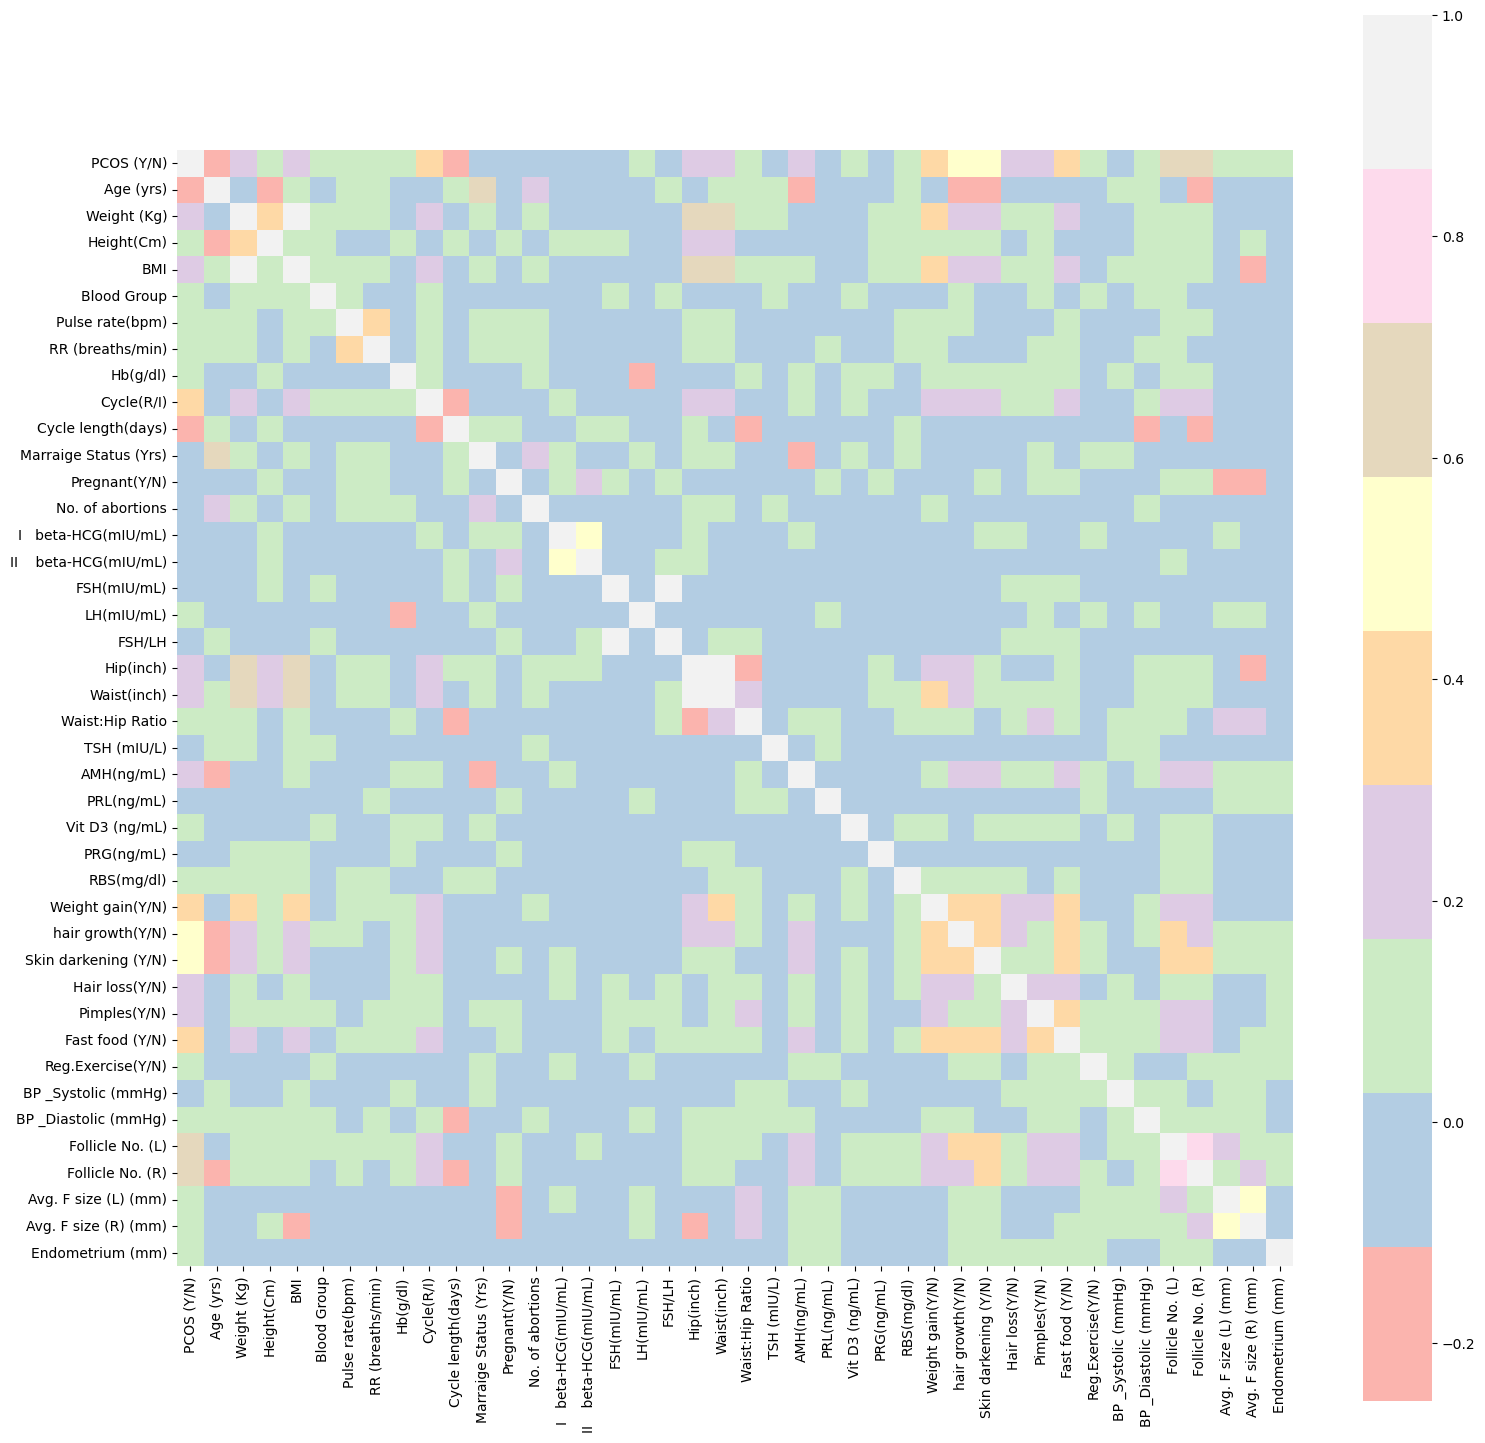

In [32]:
corrmat = df1.corr()
plt.subplots(figsize=(18,18))
sns.heatmap(corrmat,cmap="Pastel1", square=True);


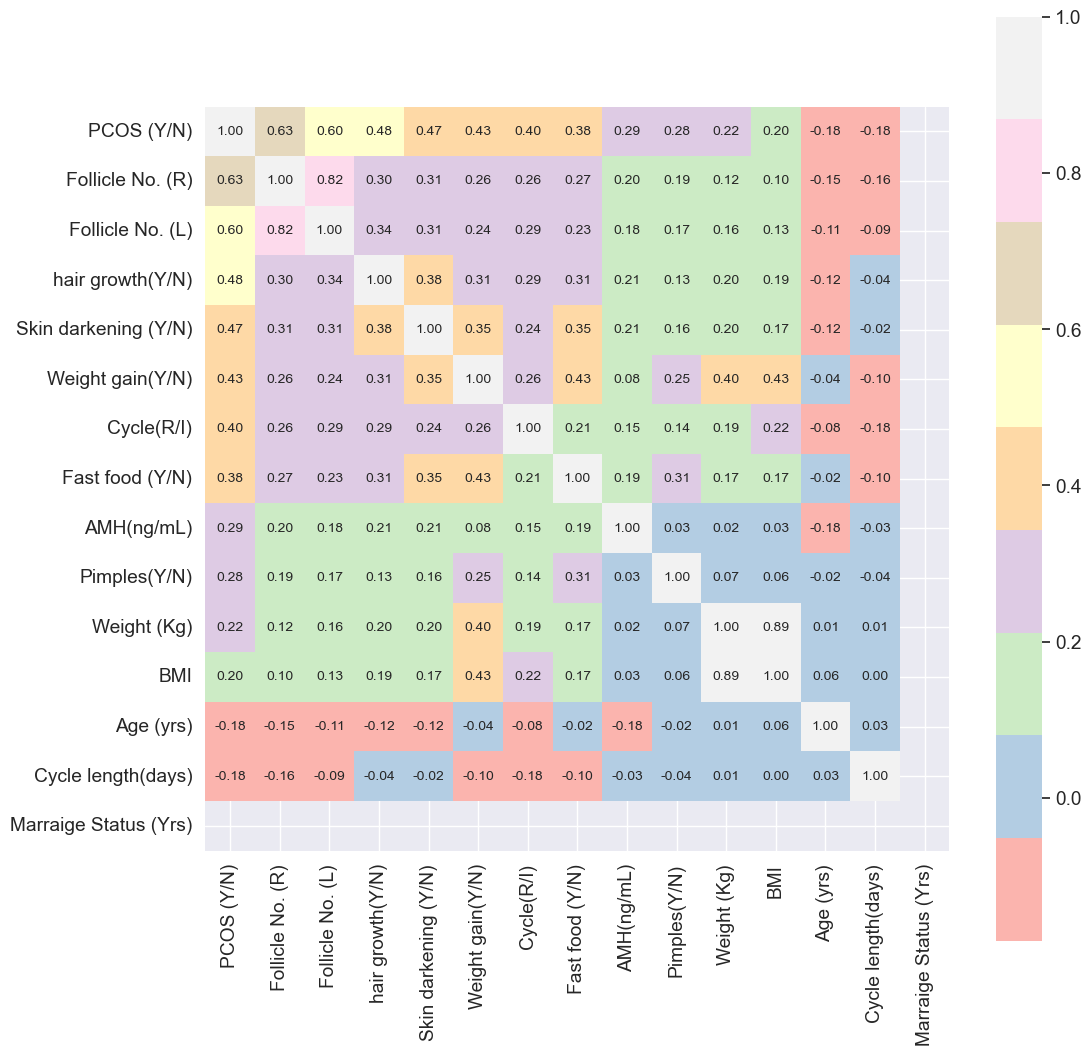

In [34]:
plt.figure(figsize=(12,12))
k = 12 #number of variables with positive for heatmap
l = 3 #number of variables with negative for heatmap
cols_p = corrmat.nlargest(k, "PCOS (Y/N)")["PCOS (Y/N)"].index 
cols_n = corrmat.nsmallest(l, "PCOS (Y/N)")["PCOS (Y/N)"].index
cols = cols_p.append(cols_n) 

cm = np.corrcoef(df1[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True,cmap="Pastel1", annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

feature selection and support vector machine start

In [ ]:
color = ["teal", "plum"]
fig=sns.lmplot(data=data,x="Age (yrs)",y="Cycle length(days)", hue="PCOS (Y/N)",palette=color)
plt.show(fig)
 